# Online Sales Data Analysis

## ABOUT DATA

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Renitia\\OneDrive\\Desktop\\data_analyst\\Portfolio\\data\\online_retail_II.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


#### Insights:
- 8 column
- 1.067.371 rows
- file size is 65.1 MB
- has missing value

## Missing Values

In [7]:
df.isnull().sum().sort_values(ascending=False)

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

#### Insights:
 The dataset has 2 columns with a significant number of missing values: 'Description' and 'Customer ID'. 
 
 - The 'Description' column has 1454 missing values
 - The 'Customer ID' column has 135080 missing values
 
 This suggests that a large portion of the data is incomplete, which may affect the analysis and insights derived from the dataset.

 ### Fill the missing values in the 'Description' Column with 'unknown'

In [8]:
df['Description'] = df['Description'].fillna('Unknown')

## PRODUCT ANALYSIS

### 1. 💰 Create Revenue Metric

In [9]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['TotalPrice'].sum()

np.float64(19287250.568)

In [10]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice'],
      dtype='str')

### 🏆 2. Top Products by Revenue

In [11]:
df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER               327813.65
DOTCOM POSTAGE                         322647.47
WHITE HANGING HEART T-LIGHT HOLDER     257533.90
JUMBO BAG RED RETROSPOT                148800.64
PARTY BUNTING                          147948.50
ASSORTED COLOUR BIRD ORNAMENT          131413.85
PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POSTAGE                                112341.00
CHILLI LIGHTS                           84854.16
ROTATING SILVER ANGELS T-LIGHT HLDR     73814.72
Name: TotalPrice, dtype: float64

📦 3. Top Products by Quantity

In [12]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

In [13]:
# Create revenue rank metric
revenue_rank = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_rank['Revenue_Rank'] = revenue_rank.index + 1

In [14]:
# Create quantity rank metric
qty_rank = (
    df.groupby('Description')['Quantity']   
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

qty_rank['Qty_Rank'] = qty_rank.index + 1

In [15]:
#Merge the two rank dataframes
merged = pd.merge(revenue_rank, qty_rank, on='Description')

In [16]:
#top 10 products by revenue rank or quantity rank
top_10 = merged[(merged['Revenue_Rank'] <= 10) | (merged['Qty_Rank'] <= 10)]
top_10

,Description,TotalPrice,Revenue_Rank,Quantity,Qty_Rank
0,REGENCY CAKESTAND 3 TIER,327813.65,1,26126,41
1,DOTCOM POSTAGE,322647.47,2,1438,1668
2,WHITE HANGING HEART T-LIGHT HOLDER,257533.90,3,93050,2
3,JUMBO BAG RED RETROSPOT,148800.64,4,78090,4
4,PARTY BUNTING,147948.50,5,28110,35
5,ASSORTED COLOUR BIRD ORNAMENT,131413.85,6,81306,3
6,PAPER CHAIN KIT 50'S CHRISTMAS,121662.14,7,35985,22
7,POSTAGE,112341.00,8,5158,516
8,CHILLI LIGHTS,84854.16,9,16702,99
9,ROTATING SILVER ANGELS T-LIGHT HLDR,73814.72,10,13775,136


In [17]:
#double top 10 products by revenue rank and quantity rank
double_top_10 = merged[(merged['Revenue_Rank'] <= 10) & (merged['Qty_Rank'] <= 10)]
double_top_10

,Description,TotalPrice,Revenue_Rank,Quantity,Qty_Rank
2,WHITE HANGING HEART T-LIGHT HOLDER,257533.90,3,93050,2
3,JUMBO BAG RED RETROSPOT,148800.64,4,78090,4
5,ASSORTED COLOUR BIRD ORNAMENT,131413.85,6,81306,3


#### Key Insights — Product Performance Analysis
- Revenue and quantity do not always align. Some products that rank high in quantity sold are not necessarily the highest in revenue, indicating differences in pricing and product value contribution.
- The product “PAPER CHAIN KIT 50'S CHRISTMAS” ranks 7th in revenue but 22nd in quantity sold, suggesting that certain products generate strong revenue despite lower sales volume.
- High-volume products tend to contribute consistently to sales activity, but they may not always be the most profitable items per unit sold.
- Revenue is concentrated in a small number of top-performing products, indicating a potential Pareto distribution (80/20 effect) in product sales performance.
- There is a clear distinction between product popularity (quantity sold) and product profitability (revenue contribution), highlighting the importance of analyzing both metrics together for better business decisions.
- If cost or margin data were available, a deeper analysis could identify true profitability and help optimize product strategy beyond just revenue and demand.

### 4. 📈 Monthly Revenue Trend

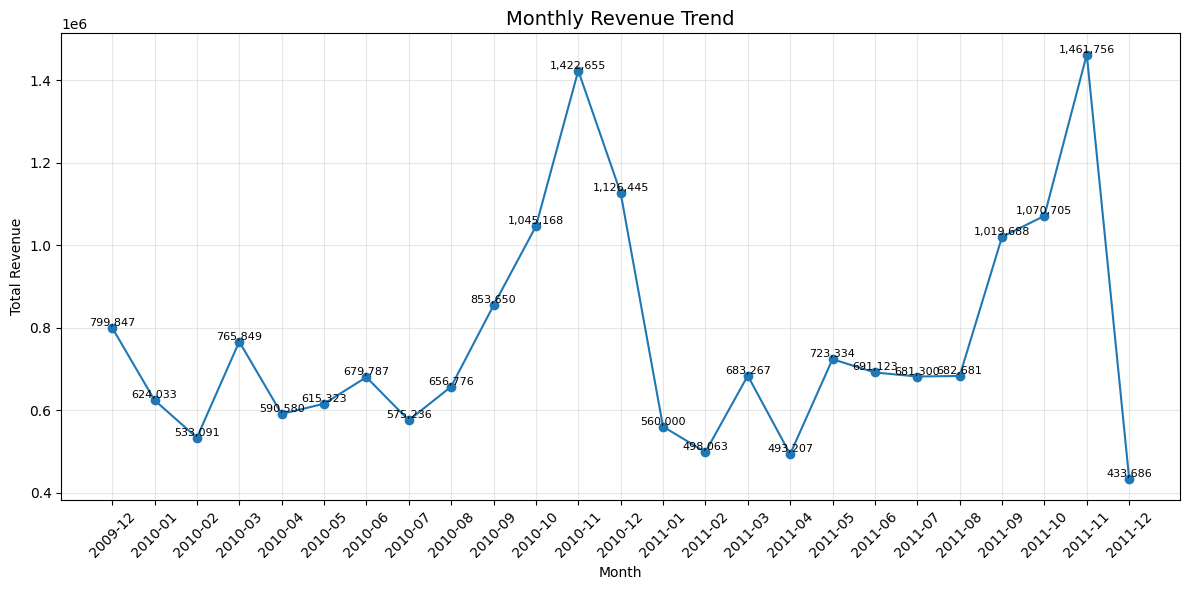

In [18]:
# datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# monthly revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reset_index()

# plot
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], marker='o')

# kasih label di setiap titik
for x, y in zip(monthly_revenue['Month'], monthly_revenue['TotalPrice']):
    ax.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

# styling biar enak dilihat
plt.xticks(rotation=45)
ax.set_title("Monthly Revenue Trend", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Insights:
- Monthly revenue shows a consistent year-over-year growth trend, indicating overall business expansion and increasing demand over time.
- Strong seasonality is observed in sales performance, with revenue consistently peaking between July and January each year.This period represents the primary sales cycle and likely accounts for a significant portion of annual revenue.
- Early months of the year generally show lower revenue, highlighting a recurring cyclical pattern in customer purchasing behavior.
- These patterns suggest that strategic planning in inventory management, marketing campaigns, and promotions should be prioritized ahead of peak months to maximize revenue performance.

### 5. 🌍 Revenue by Country

In [19]:
# how many unique countries
df['Country'].nunique()

43

In [20]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)  

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: TotalPrice, dtype: float64

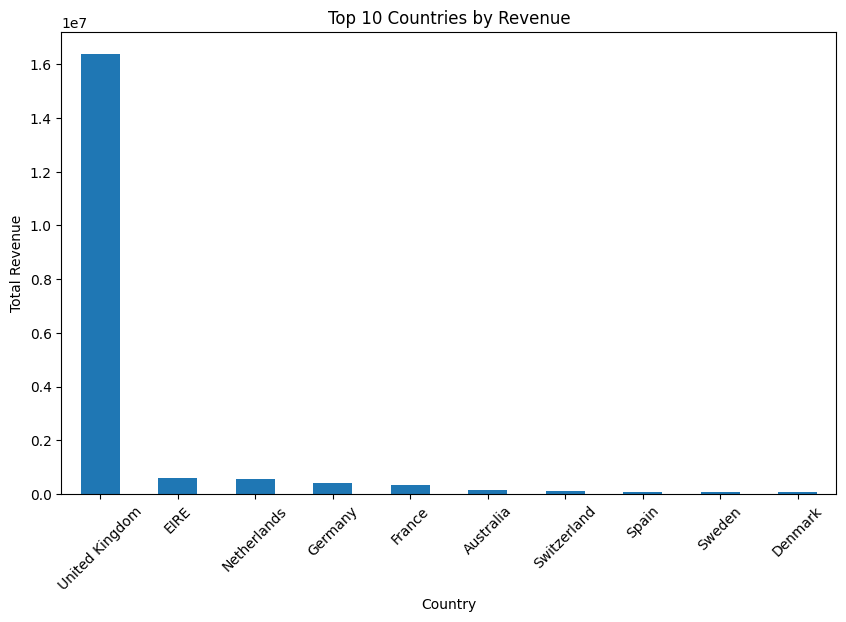

In [21]:
# plot top 10 countries by revenue
import matplotlib.pyplot as plt

top_10_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

#### Insight 

The majority of revenue comes from the United Kingdom, which is expected as the retail store is based in the UK. This indicates strong domestic market dominance.

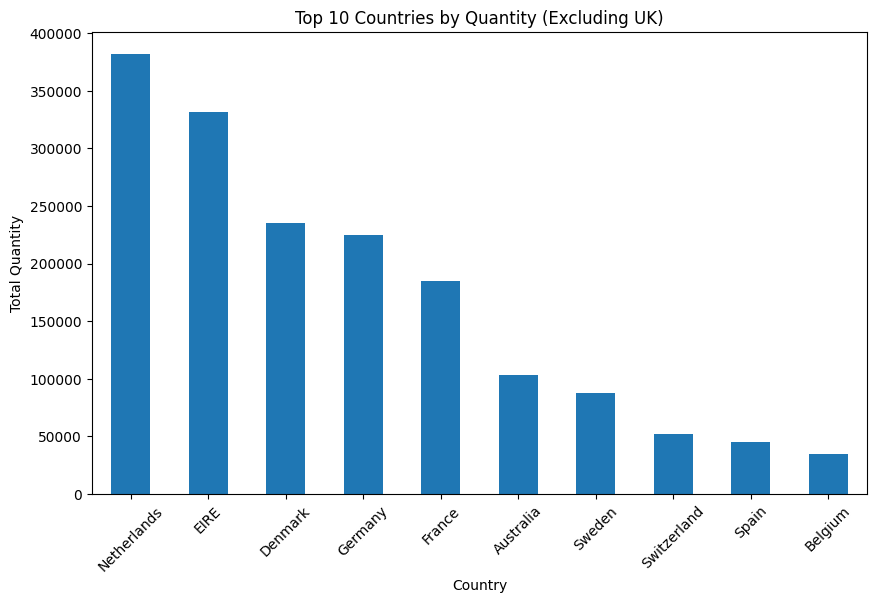

In [22]:
#plot top 10 countries by quantity exclude United Kingdom
top_10_countries_qty = df[df['Country'] != 'United Kingdom'].groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6)) 
top_10_countries_qty.plot(kind='bar')
plt.title('Top 10 Countries by Quantity (Excluding UK)')
plt.xlabel('Country')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)
plt.show()

#### Insights:
- When excluding the UK from the analysis, revenue distribution changes significantly, with the Netherlands and the Republic of Ireland (EIRE) emerging as the top-performing international markets.
- This suggests that while the UK drives the core revenue base, there is also meaningful demand in select European markets, particularly in the Netherlands and Ireland.
- The findings highlight the importance of both maintaining strong domestic performance and exploring targeted growth opportunities in high-performing international regions.


1. Revenue definition

→ TotalPrice

2. What makes money

→ Top products by revenue

3. What is popular

→ Quantity analysis

4. When money comes

→ Monthly trend

5. Where money comes from

→ Country analysis



# CUSTOMER ANALYSIS

In [27]:
# cleaning data for customer analysis
df_clean = df[df['Customer ID'].notnull()]

# cleaning invalid quantity and price values
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# cleaning invalid invoice numbers
df_clean = df_clean[df_clean['Invoice'].str.startswith('C') == False]

Transactions with missing Customer IDs were excluded because RFM analysis requires customer-level identification to calculate recency, frequency, and monetary metrics accurately.

In [28]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [33]:
# recency, frequency, monetary value (RFM) analysis

rfm = (
    df_clean.assign(
        TotalPrice=df_clean['Quantity'] * df_clean['Price']
    )
    .groupby('Customer ID')
    .agg(
        last_purchase=('InvoiceDate', 'max'),
        frequency=('Invoice', 'nunique'),
        monetary=('TotalPrice', 'sum')
    )
)

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm['recency'] = (
    snapshot_date - rfm['last_purchase']
).dt.days

In [34]:
rfm.head()

,last_purchase,frequency,monetary,recency
Customer ID,,,,
12346.0,2011-01-18 10:01:00,12,77556.46,326
12347.0,2011-12-07 15:52:00,8,5633.32,2
12348.0,2011-09-25 13:13:00,5,2019.40,75
12349.0,2011-11-21 09:51:00,4,4428.69,19
12350.0,2011-02-02 16:01:00,1,334.40,310


In [ ]:
# top 10 customers by frequency
top_customers_freq = rfm.sort_values(by='frequency', ascending=False)
top_customers_freq.head(10)


,last_purchase,frequency,monetary,recency
Customer ID,,,,
14911.0,2011-12-08 15:54:00,398,295972.63,1
12748.0,2011-12-09 12:20:00,336,56599.39,1
17841.0,2011-12-08 12:07:00,211,70884.07,2
15311.0,2011-12-09 12:00:00,208,116771.16,1
13089.0,2011-12-07 09:02:00,203,116737.86,3
14606.0,2011-12-08 19:28:00,192,30861.06,1
14156.0,2011-11-30 10:54:00,156,313946.37,10
17850.0,2010-12-02 15:27:00,155,56600.08,372
14646.0,2011-12-08 12:12:00,151,528602.52,2


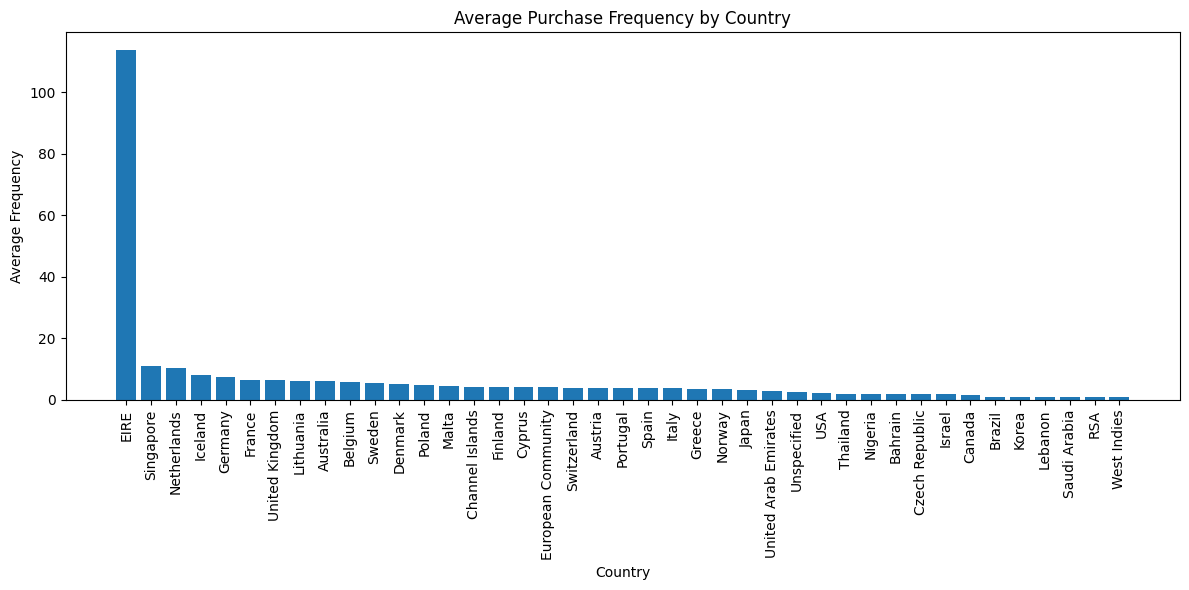

In [50]:
# Add country to rfm
rfm['Country'] = (
    df_clean.groupby('Customer ID')['Country']
    .first()
)

# Calculate average frequency by country
country_avg_freq = (
    rfm.groupby('Country')['frequency']
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(country_avg_freq.index, country_avg_freq.values)

plt.xlabel('Country')
plt.ylabel('Average Frequency')
plt.title('Average Purchase Frequency by Country')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Although the United Kingdom contributes the largest customer base and transaction volume, customers from EIRE exhibit a higher average purchase frequency, indicating a smaller but more engaged customer segment. However, this finding should be interpreted alongside customer count, as countries with fewer customers can produce higher average values.

In [64]:
# make a table with average frequency, country, and number of customers
country_summary = (
    rfm.groupby('Country')
    .agg(
        avg_frequency=('frequency', 'mean'),
        num_customers=('frequency', 'count')
    )
    .sort_values(by='avg_frequency', ascending=False)
)

country_summary.head(10)

,avg_frequency,num_customers
Country,,
EIRE,113.800000,5
Singapore,11.000000,1
Netherlands,10.363636,22
Iceland,8.000000,1
Germany,7.383178,107
France,6.559140,93
United Kingdom,6.270144,5349
Lithuania,6.000000,1
Australia,5.928571,14


Average Purchase Frequency by Country

Although the United Kingdom accounts for the largest customer base in the dataset, it does not have the highest average purchase frequency. When countries are ranked by the average number of purchases per customer, the United Kingdom ranks 7th.

This result may seem surprising at first, but it becomes more understandable when considering the distribution of customers across countries.

The United Kingdom has 5,349 customers, significantly more than any other country in the dataset. With such a large customer base, purchasing behavior is naturally more diverse, ranging from one-time buyers to highly loyal customers. This broader variation lowers the overall average purchase frequency.

In contrast, countries such as EIRE have a much smaller customer base but demonstrate higher average purchase frequency, suggesting a more concentrated group of highly engaged customers.

Key takeaway:

A larger customer base does not necessarily lead to a higher average purchase frequency.
The United Kingdom drives the majority of transactions through scale, while smaller markets like EIRE may exhibit stronger customer engagement on a per-customer basis.
Average metrics should always be interpreted alongside customer counts to avoid misleading conclusions.

In [58]:
rfm.head()

,last_purchase,frequency,monetary,recency,Country
Customer ID,,,,,
12346.0,2011-01-18 10:01:00,12,77556.46,326,United Kingdom
12347.0,2011-12-07 15:52:00,8,5633.32,2,Iceland
12348.0,2011-09-25 13:13:00,5,2019.40,75,Finland
12349.0,2011-11-21 09:51:00,4,4428.69,19,Italy
12350.0,2011-02-02 16:01:00,1,334.40,310,Norway


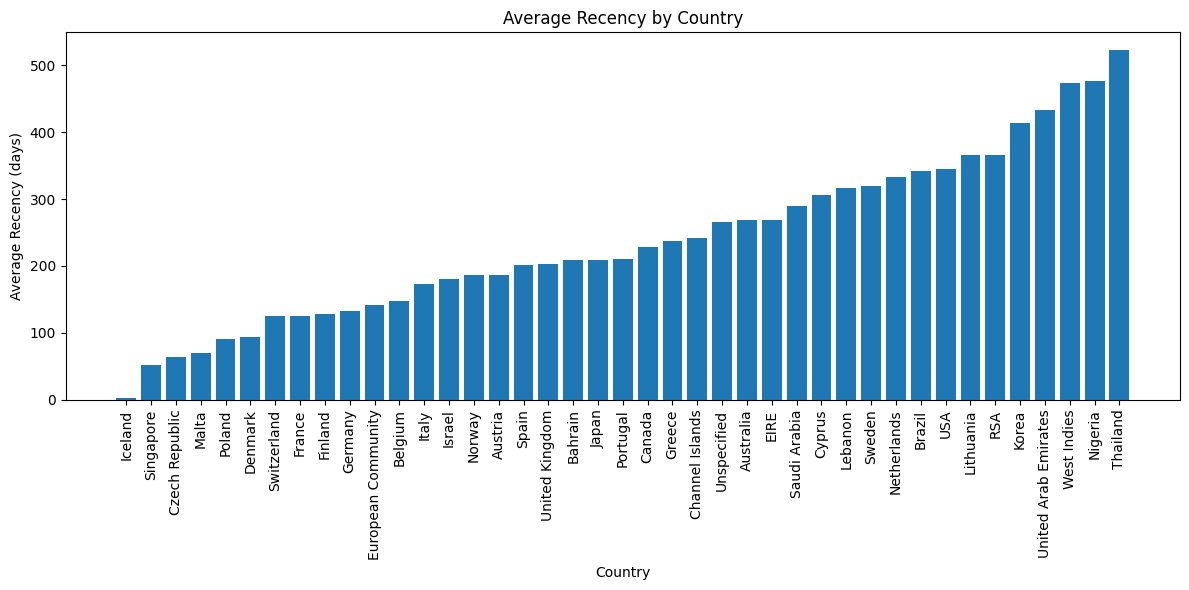

In [63]:
# calculate avarage recency by country
country_avg_recency = (
    rfm.groupby('Country')['recency']
    .mean()
    .sort_values(ascending=True)
)

#plot average recency by country
plt.figure(figsize=(12, 6))
plt.bar(country_avg_recency.index, country_avg_recency.values)
plt.xlabel('Country')
plt.ylabel('Average Recency (days)')
plt.title('Average Recency by Country')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [61]:
country_avg_recency.head(10)

Country
Iceland             2.000000
Singapore          52.000000
Czech Republic     64.000000
Malta              69.500000
Poland             91.500000
Denmark            93.272727
Switzerland       124.904762
France            125.494624
Finland           128.857143
Germany           133.074766
Name: recency, dtype: float64

Iceland recorded the lowest average recency, indicating that its customers made purchases more recently than customers from other countries. However, this result should be interpreted with caution due to the relatively small customer base. In contrast, the United Kingdom ranked 11th despite having the largest customer base (5,349 customers). The broader customer mix in the UK, ranging from highly active to inactive customers, likely contributes to its higher average recency.

,avg_frequency,num_customers,avg_recency_x,avg_recency_y,avg_recency,country_avg_recency_x,country_avg_recency_y
Country,,,,,,,
EIRE,113.800000,5,268.400000,268.400000,268.400000,268.400000,268.400000
Singapore,11.000000,1,52.000000,52.000000,52.000000,52.000000,52.000000
Netherlands,10.363636,22,332.681818,332.681818,332.681818,332.681818,332.681818
Iceland,8.000000,1,2.000000,2.000000,2.000000,2.000000,2.000000
Germany,7.383178,107,133.074766,133.074766,133.074766,133.074766,133.074766


In [72]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  str           
 1   StockCode    805549 non-null  str           
 2   Description  805549 non-null  str           
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   TotalPrice   805549 non-null  float64       
 9   Month        805549 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(5)
memory usage: 67.6 MB


In [73]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 5878 entries, 12346.0 to 18287.0
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   last_purchase  5878 non-null   datetime64[us]
 1   frequency      5878 non-null   int64         
 2   monetary       5878 non-null   float64       
 3   recency        5878 non-null   int64         
 4   Country        5878 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 275.5 KB


In [74]:
rfm.head()


,last_purchase,frequency,monetary,recency,Country
Customer ID,,,,,
12346.0,2011-01-18 10:01:00,12,77556.46,326,United Kingdom
12347.0,2011-12-07 15:52:00,8,5633.32,2,Iceland
12348.0,2011-09-25 13:13:00,5,2019.40,75,Finland
12349.0,2011-11-21 09:51:00,4,4428.69,19,Italy
12350.0,2011-02-02 16:01:00,1,334.40,310,Norway


In [77]:
# rfm score

rfm['R_score'] = pd.qcut(
    rfm['recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Add score

rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

top_customers = rfm.sort_values(
    by='RFM_score',
    ascending=False
)

top_customers.head(10)

,last_purchase,frequency,monetary,recency,Country,R_score,F_score,M_score,RFM_score
Customer ID,,,,,,,,,
16705.0,2011-12-09 12:08:00,42,43515.051,1,United Kingdom,5,5,5,555
14572.0,2011-12-06 14:40:00,11,5615.180,3,United Kingdom,5,5,5,555
18055.0,2011-12-02 14:25:00,14,11195.570,7,United Kingdom,5,5,5,555
17173.0,2011-12-04 14:40:00,8,3766.600,5,United Kingdom,5,5,5,555
14505.0,2011-11-22 15:45:00,19,12001.840,17,United Kingdom,5,5,5,555
13709.0,2011-12-06 10:28:00,18,7591.750,4,United Kingdom,5,5,5,555
12955.0,2011-12-08 16:29:00,11,4757.160,1,United Kingdom,5,5,5,555
14515.0,2011-11-22 11:37:00,12,3749.260,18,United Kingdom,5,5,5,555
12957.0,2011-11-30 09:53:00,13,8706.970,10,United Kingdom,5,5,5,555


In [78]:
def segment_customer(row):
    r = row['R_score']
    f = row['F_score']

    if r >= 4 and f >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f <= 2:
        return 'New Customers'

    elif r >= 3 and f == 3:
        return 'Potential Loyalists'

    elif r <= 2 and f >= 4:
        return 'At Risk'

    elif r <= 2 and f <= 2:
        return 'Lost Customers'

    else:
        return 'Needs Attention'

In [79]:
rfm['segment'] = rfm.apply(segment_customer, axis=1)

rfm['segment'].value_counts()

segment
Lost Customers         1523
Champions              1482
Needs Attention         856
Potential Loyalists     705
Loyal Customers         516
New Customers           443
At Risk                 353
Name: count, dtype: int64

In [80]:
segment_summary = (
    rfm.groupby('segment')
    .agg(
        customers=('segment', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        total_revenue=('monetary', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
)

segment_summary

,customers,avg_recency,avg_frequency,total_revenue
segment,,,,
Champions,1482,20.367072,15.657895,1.229314e+07
Loyal Customers,516,106.294574,8.534884,1.721052e+06
At Risk,353,344.212465,7.572238,1.126231e+06
Potential Loyalists,705,58.278014,3.134752,8.278853e+05
Needs Attention,856,261.528037,2.245327,7.133614e+05
Lost Customers,1523,459.281024,1.252791,6.671219e+05
New Customers,443,28.106095,1.460497,3.946386e+05


| Segment                 | Characteristics                                             | Business Interpretation                                                | Recommended Action                                                                       |
| ----------------------- | ----------------------------------------------------------- | ---------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Champions**           | Recently purchased, buy frequently, and spend the most      | The most valuable customers who drive a significant portion of revenue | Reward loyalty through exclusive offers, VIP programs, and early access to new products  |
| **Loyal Customers**     | Purchase regularly and maintain strong engagement           | Consistent customers with high long-term value                         | Encourage repeat purchases through personalized recommendations and cross-selling        |
| **Potential Loyalists** | Recently active with moderate purchase frequency            | Customers showing strong potential to become loyal buyers              | Increase engagement with targeted promotions and personalized communication              |
| **New Customers**       | Recently made their first few purchases                     | New customers who are still exploring the brand                        | Build relationships through welcome campaigns and onboarding offers                      |
| **Needs Attention**     | Moderate recency and frequency                              | Customers whose engagement may be declining                            | Re-engage them with reminders, tailored offers, or product recommendations               |
| **At Risk**             | Previously active customers who have not purchased recently | Valuable customers with a high likelihood of churning                  | Launch retention campaigns, such as limited-time discounts or personalized outreach      |
| **Lost Customers**      | Low recency, low frequency, and low spending                | Customers who have likely churned                                      | Consider win-back campaigns or evaluate whether reacquisition efforts are cost-effective |


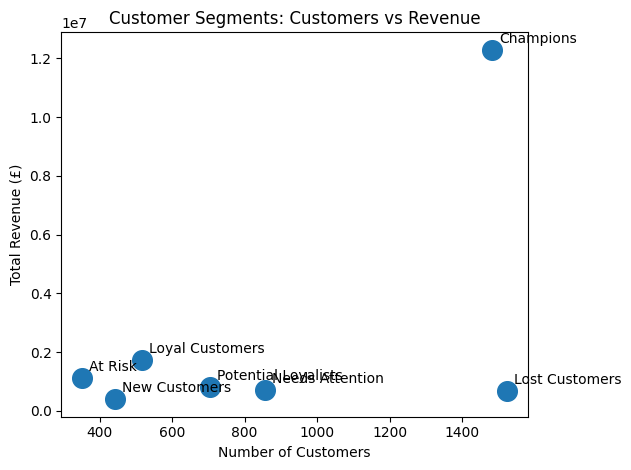

In [84]:
plt.scatter(
    segment_summary['customers'],
    segment_summary['total_revenue'],
    s=200
)

for segment, row in segment_summary.iterrows():
    plt.annotate(
        segment,
        (row['customers'], row['total_revenue']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Number of Customers')
plt.ylabel('Total Revenue (£)')
plt.title('Customer Segments: Customers vs Revenue')

plt.tight_layout()
plt.show()

In [85]:
segment_pct = segment_summary.copy()

segment_pct['customer_pct'] = (
    segment_pct['customers']
    / segment_pct['customers'].sum()
    * 100
)

segment_pct['revenue_pct'] = (
    segment_pct['total_revenue']
    / segment_pct['total_revenue'].sum()
    * 100
)

segment_pct

,customers,avg_recency,avg_frequency,total_revenue,customer_pct,revenue_pct
segment,,,,,,
Champions,1482,20.367072,15.657895,1.229314e+07,25.212657,69.282767
Loyal Customers,516,106.294574,8.534884,1.721052e+06,8.778496,9.699660
At Risk,353,344.212465,7.572238,1.126231e+06,6.005444,6.347313
Potential Loyalists,705,58.278014,3.134752,8.278853e+05,11.993875,4.665870
Needs Attention,856,261.528037,2.245327,7.133614e+05,14.562776,4.020426
Lost Customers,1523,459.281024,1.252791,6.671219e+05,25.910174,3.759825
New Customers,443,28.106095,1.460497,3.946386e+05,7.536577,2.224139


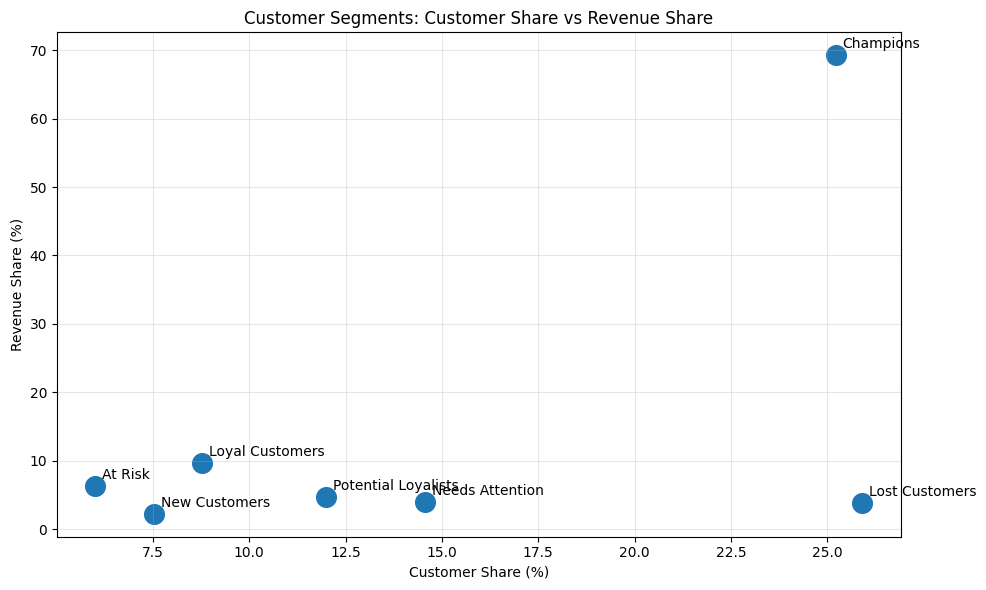

In [86]:
plt.figure(figsize=(10, 6))

plt.scatter(
    segment_pct['customer_pct'],
    segment_pct['revenue_pct'],
    s=200
)

for segment, row in segment_pct.iterrows():
    plt.annotate(
        segment,
        (row['customer_pct'], row['revenue_pct']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Customer Share (%)')
plt.ylabel('Revenue Share (%)')
plt.title('Customer Segments: Customer Share vs Revenue Share')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Key Insights

### 1. Champions Drive the Majority of Revenue

The **Champions** segment represents only **25.2% of the customer base** but contributes **69.3% of total revenue**, making it the most valuable customer group.

With an average recency of **20 days** and an average purchase frequency of **15.7 transactions**, these customers demonstrate strong engagement and high spending behavior.

This finding highlights a significant revenue concentration among a relatively small group of highly valuable customers.

---

### 2. Loyal Customers Offer Strong Growth Opportunities

Although **Loyal Customers** account for only **8.8% of customers**, they contribute **9.7% of total revenue**.

Their relatively high purchase frequency indicates strong long-term value and suggests opportunities for cross-selling, upselling, and personalized marketing campaigns.

---

### 3. Lost Customers Represent a Large Portion of the Customer Base

The **Lost Customers** segment accounts for the largest share of customers (**25.9%**) but contributes only **3.8% of total revenue**.

With an average recency of **459 days** and low purchase frequency, these customers are unlikely to return without targeted win-back initiatives.

---

### 4. At-Risk Customers Require Immediate Attention

Customers classified as **At Risk** represent **6.0% of the customer base** and contribute **6.3% of total revenue**.

Despite their relatively low recency score, they maintain a high average purchase frequency (**7.6 transactions**), indicating that they were previously valuable customers who may be in danger of churning.

Retention campaigns targeting this segment could help prevent potential revenue loss.

---

### 5. New and Potential Loyalists Show Future Growth Potential

Together, **New Customers** and **Potential Loyalists** represent nearly **19.5% of the customer base** while contributing **6.9% of total revenue**.

These segments have relatively recent purchase activity and present an opportunity to increase customer lifetime value through onboarding programs, personalized recommendations, and engagement campaigns.

---

### 6. Revenue Distribution Is Highly Uneven Across Customer Segments

The analysis reveals that revenue is concentrated among a small number of highly engaged customers.

While **Champions** and **Loyal Customers** together account for only **34.0% of customers**, they generate approximately **79.0% of total revenue**.

This pattern emphasizes the importance of customer retention strategies focused on high-value segments.


In [89]:
pareto = (
    rfm[['monetary']]
    .sort_values('monetary', ascending=False)
)

pareto['cum_revenue_pct'] = (
    pareto['monetary'].cumsum()
    / pareto['monetary'].sum()
    * 100
)

pareto['cum_customer_pct'] = (
    np.arange(1, len(pareto) + 1)
    / len(pareto)
    * 100
)

In [90]:
top_customers_pct = pareto[
    pareto['cum_revenue_pct'] <= 80
]['cum_customer_pct'].max()

print(top_customers_pct)

23.001020755358965


### 7. Revenue Follows a Pareto-Like Distribution

A Pareto analysis revealed that the top 23% of customers generate approximately 80% of total revenue.

This finding indicates a strong concentration of revenue among a relatively small group of customers, highlighting the importance of identifying, retaining, and nurturing high-value segments.

The result aligns closely with the Pareto Principle (80/20 rule), which suggests that a minority of customers often contributes the majority of business value.

Business implication: Retention efforts should prioritize high-value customers, particularly those classified as Champions and Loyal Customers, as losing these customers could have a disproportionate impact on overall revenue.